In [ ]:
!pip install phik
!pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 8.6 MB/s eta 0:00:00


In [ ]:

import pandas as pd
import os
import pandas as pd
import kagglehub
from tqdm.notebook import tqdm
import phik
from phik import resources, report
from datetime import datetime
import numpy as np
import seaborn as sns

In [ ]:
dataset_path = kagglehub.dataset_download("radistaleks/synthetic-bank-transactions")
files = [f for f in os.listdir(dataset_path) if f.endswith(('.csv', '.parquet', '.json'))]
categories = pd.read_csv(os.path.join(dataset_path, "categories.csv"))
clients = pd.read_csv(os.path.join(dataset_path, "clients.csv"))
subscriptions = pd.read_csv(os.path.join(dataset_path, "subscriptions.csv"))
transactions = pd.read_csv(os.path.join(dataset_path, "transactions.csv"))  # или другой файл

100%|██████████| 13.2M/13.2M [00:01<00:00, 9.64MB/s]

Extracting files...


In [ ]:
categories[categories['id'] == 28] = categories[categories['id'] == 28].fillna(4829)

/tmp/ipython-input-2679728942.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  categories[categories['id'] == 28] = categories[categories['id'] == 28].fillna(4829)


In [ ]:
categories[categories['id'] == 29] = categories[categories['id'] == 29].fillna(4900)

/tmp/ipython-input-4254145341.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  categories[categories['id'] == 29] = categories[categories['id'] == 29].fillna(4900)


In [ ]:
categories.head()

,id,name,description,mcc-code
0,1,Каршеринг,Краткосрочная аренда авто с оплатой по минутам...,"7512, 4121"
1,2,Супермаркеты,Покупки в супермаркетах и продуктовых магазинах,"5297, 5298, 5300, 5411, 5412, 5422, 5441, 5451..."
2,3,Такси,Услуги такси (каршеринг не входит в данную кат...,4121
3,4,Музыка,Покупки в магазинах музыки и музыкальных инстр...,"5733, 5735"
4,5,Фастфуд,Покупки в ресторанах быстрого питания,5814


In [ ]:
clients.head()

,id,fullname,address,phone_number,email,workplace,birthdate,registration_date,gender,income,expenses,credit,deposit
0,1,Волкова Фаина Афанасьевна,"с. Новосибирск, наб. Привокзальная, д. 58 к. 5...",8 (475) 014-6494,wkirillov@rambler.ru,"ст. Кировск (Мурм.), ш. Коммуны, д. 238 стр. 3...",1966-09-07,2017-01-10,F,230910.0,61975,1.0,NaN
1,2,Пелагея Вячеславовна Галкина,"клх Белокуриха, ш. Комсомольское, д. 701 стр. ...",+7 (981) 576-1146,bogdanovmoke@rambler.ru,"г. Елабуга, бул. 60 лет Октября, д. 5, 070955",1987-05-23,2016-07-14,F,NaN,75232,NaN,NaN
2,3,Валентина Игоревна Фомина,"к. Усть-Катав, бул. Восточный, д. 292 стр. 3, ...",+7 (920) 068-58-36,mjasnikovvalentin@mail.ru,"г. Сосновый Бор, алл. Лесхозная, д. 146, 139446",1974-06-15,2017-10-18,F,NaN,88813,NaN,NaN
3,4,тов. Воронцова Фёкла Федоровна,"клх Новая Игирма, алл. Пограничная, д. 6/6, 73...",8 334 398 3828,martin85@rambler.ru,"клх Котельнич, бул. Серафимовича, д. 97, 753076",1979-10-19,2012-08-25,F,NaN,55167,NaN,NaN
4,5,Филипп Дмитриевич Воронцов,"к. Ребриха, пр. Свободы, д. 54, 466509",8 (296) 455-0453,jan_07@rambler.ru,"клх Карабудахкент, ул. Абрикосовая, д. 3 к. 19...",1986-08-14,2017-03-15,M,NaN,85106,NaN,NaN


In [ ]:
clients['registration_date'] = pd.to_datetime(clients['registration_date'])

In [ ]:
clients['deposit'].value_counts()

,count
deposit,
1.0,376


In [ ]:
clients['credit'].value_counts()

,count
credit,
1.0,364


In [ ]:
clients = clients.fillna(0)

In [ ]:
subscriptions.head()

,id,client_id,product_category,product_company,amount,date_start,date_end
0,766278,825,29,NaN,3990,2012-01-25,NaN
1,658393,709,4,Яндекс.Музыка,199,2012-01-27,2020-02-27
2,354548,383,4,Boom,149,2012-01-28,NaN
3,515830,556,4,Spotify,169,2012-02-01,NaN
4,799560,862,4,YouTube Music,169,2012-02-20,2020-05-20


In [ ]:
subscriptions.isna().mean()

,0
id,0.000000
client_id,0.000000
product_category,0.000000
product_company,0.387615
amount,0.000000
date_start,0.000000
date_end,0.782875


In [ ]:
subscriptions.phik_matrix()

interval columns not set, guessing: ['id', 'client_id', 'product_category', 'amount']


,id,client_id,product_category,product_company,amount,date_start,date_end
id,1.000000,0.999982,0.000000,0.0,0.000000,0.136345,0.0
client_id,0.999982,1.000000,0.000000,0.0,0.000000,0.138820,0.0
product_category,0.000000,0.000000,1.000000,NaN,0.999739,0.319794,0.0
product_company,0.000000,0.000000,NaN,1.0,NaN,0.000000,0.0
amount,0.000000,0.000000,0.999739,NaN,1.000000,0.000000,0.0
date_start,0.136345,0.138820,0.319794,0.0,0.000000,1.000000,0.0
date_end,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.0


In [ ]:
subscriptions.isna().mean()

,0
id,0.000000
client_id,0.000000
product_category,0.000000
product_company,0.387615
amount,0.000000
date_start,0.000000
date_end,0.782875


In [ ]:
subscriptions['product_company'] = subscriptions['product_company'].fillna('Неизвестно')

In [ ]:
subscriptions['date_end'] = pd.to_datetime(subscriptions['date_end'])

In [ ]:
subscriptions['date_start'] = pd.to_datetime(subscriptions['date_start'])

In [ ]:
subscriptions['date_end'].describe()

,date_end
count,284
mean,2020-07-24 18:35:29.577464832
min,2020-02-02 00:00:00
25%,2020-04-30 06:00:00
50%,2020-08-01 12:00:00
75%,2020-10-13 12:00:00
max,2020-12-28 00:00:00


In [ ]:
subscriptions['date_start'].describe()

,date_start
count,1308
mean,2018-03-02 19:02:45.137614848
min,2012-01-25 00:00:00
25%,2017-01-18 00:00:00
50%,2018-08-12 00:00:00
75%,2019-09-24 00:00:00
max,2020-11-28 00:00:00


In [ ]:
transactions.head()

,Unnamed: 0,client_id,product_category,product_company,subtype,amount,date,transaction_type
0,34478,37,29,NaN,Автоплатеж,1209,2020-01-01 00:00:00,Negative
1,65406,71,4,YouTube Music,Подписка,169,2020-01-01 00:00:00,Negative
2,82186,88,29,NaN,Автоплатеж,3711,2020-01-01 00:00:00,Negative
3,83113,89,29,NaN,Автоплатеж,6443,2020-01-01 00:00:00,Negative
4,131373,141,29,NaN,Автоплатеж,7319,2020-01-01 00:00:00,Negative


In [ ]:
transactions['product_company'] = transactions['product_company'].fillna('Неизвестно')

In [ ]:
transactions.isna().mean()

,0
Unnamed: 0,0.0
client_id,0.0
product_category,0.0
product_company,0.0
subtype,0.0
amount,0.0
date,0.0
transaction_type,0.0


In [ ]:
transactions['date'] = pd.to_datetime(transactions['date'],format='%Y-%m-%d %H:%M:%S')

In [ ]:
transactions.head(1000).phik_matrix()

interval columns not set, guessing: ['Unnamed: 0', 'client_id', 'product_category', 'amount']


,Unnamed: 0,client_id,product_category,product_company,subtype,amount,date,transaction_type
Unnamed: 0,1.000000,0.999990,0.076172,0.055331,0.000000,0.023898,0.458019,0.000000
client_id,0.999990,1.000000,0.088494,0.084789,0.000000,0.029561,0.460755,0.000000
product_category,0.076172,0.088494,1.000000,0.961701,0.697738,0.355669,0.953600,0.630749
product_company,0.055331,0.084789,0.961701,1.000000,0.807653,0.000000,0.000000,0.267900
subtype,0.000000,0.000000,0.697738,0.807653,1.000000,0.000000,0.000000,1.000000
amount,0.023898,0.029561,0.355669,0.000000,0.000000,1.000000,1.000000,0.000000
date,0.458019,0.460755,0.953600,0.000000,0.000000,1.000000,1.000000,0.965017
transaction_type,0.000000,0.000000,0.630749,0.267900,1.000000,0.000000,0.965017,1.000000


In [ ]:
subscriptions.head()

,id,client_id,product_category,product_company,amount,date_start,date_end
0,766278,825,29,Неизвестно,3990,2012-01-25,NaT
1,658393,709,4,Яндекс.Музыка,199,2012-01-27,2020-02-27
2,354548,383,4,Boom,149,2012-01-28,NaT
3,515830,556,4,Spotify,169,2012-02-01,NaT
4,799560,862,4,YouTube Music,169,2012-02-20,2020-05-20


In [ ]:
transactions[transactions['amount']>7000]['product_company'].value_counts()

,count
product_company,
Неизвестно,11385
WILDBERRIES,1376
H&M,1348
Marks&Spencer,1332
Lamoda,1331
Bershka,1304
Zara,1300


In [ ]:
transactions['date_d'] = transactions['date'].dt.normalize()

In [ ]:
transactions

,Unnamed: 0,client_id,product_category,product_company,subtype,amount,date,transaction_type,date_d
0,34478,37,29,Неизвестно,Автоплатеж,1209,2020-01-01 00:00:00,Negative,2020-01-01
1,65406,71,4,YouTube Music,Подписка,169,2020-01-01 00:00:00,Negative,2020-01-01
2,82186,88,29,Неизвестно,Автоплатеж,3711,2020-01-01 00:00:00,Negative,2020-01-01
3,83113,89,29,Неизвестно,Автоплатеж,6443,2020-01-01 00:00:00,Negative,2020-01-01
4,131373,141,29,Неизвестно,Автоплатеж,7319,2020-01-01 00:00:00,Negative,2020-01-01
...,...,...,...,...,...,...,...,...,...
929130,11637,13,6,Стрелка,Покупка,50,2020-12-31 23:58:04,Negative,2020-12-31
929131,179338,194,6,Неизвестно,Покупка,54,2020-12-31 23:58:11,Negative,2020-12-31
929132,511244,551,3,Ситимобил,Покупка,313,2020-12-31 23:58:13,Negative,2020-12-31
929133,214793,232,6,Неизвестно,Покупка,87,2020-12-31 23:59:03,Negative,2020-12-31


<Axes: xlabel='date_d'>

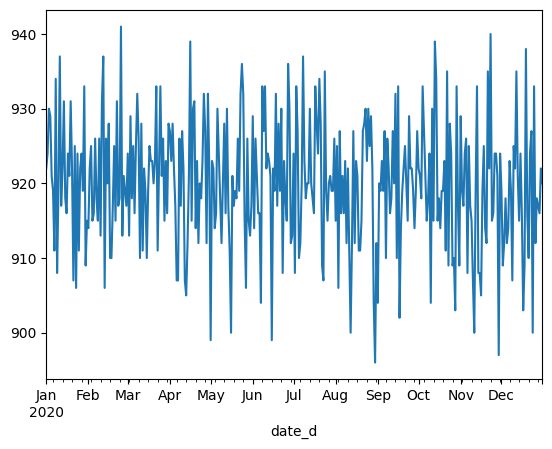

In [ ]:
transactions.groupby('date_d')['client_id'].nunique().sort_index().plot()

<Axes: >

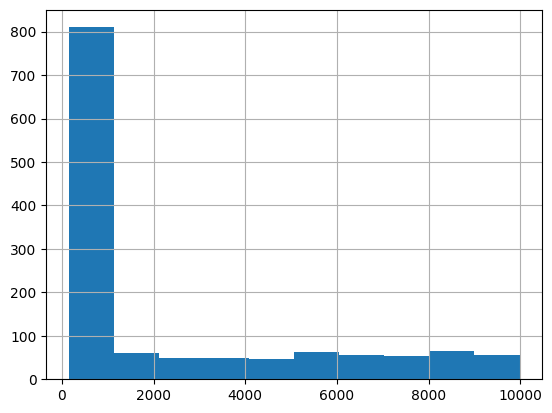

In [ ]:
subscriptions['amount'].hist()

In [ ]:
subscriptions

,id,client_id,product_category,product_company,amount,date_start,date_end
0,766278,825,29,Неизвестно,3990,2012-01-25,NaT
1,658393,709,4,Яндекс.Музыка,199,2012-01-27,2020-02-27
2,354548,383,4,Boom,149,2012-01-28,NaT
3,515830,556,4,Spotify,169,2012-02-01,NaT
4,799560,862,4,YouTube Music,169,2012-02-20,2020-05-20
...,...,...,...,...,...,...,...
1303,529611,571,4,Яндекс.Музыка,199,2020-11-15,NaT
1304,427199,461,4,Spotify,169,2020-11-18,NaT
1305,464986,501,29,Неизвестно,6884,2020-11-20,NaT
1306,425121,458,29,Неизвестно,9202,2020-11-25,NaT


<Axes: xlabel='date_start'>

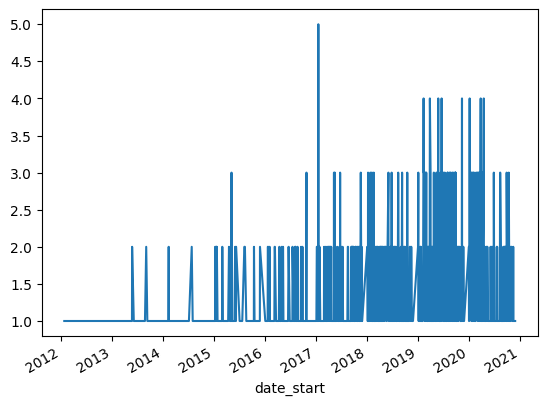

In [ ]:
subscriptions.groupby('date_start')['client_id'].count().sort_index().plot()

<Axes: xlabel='date_end'>

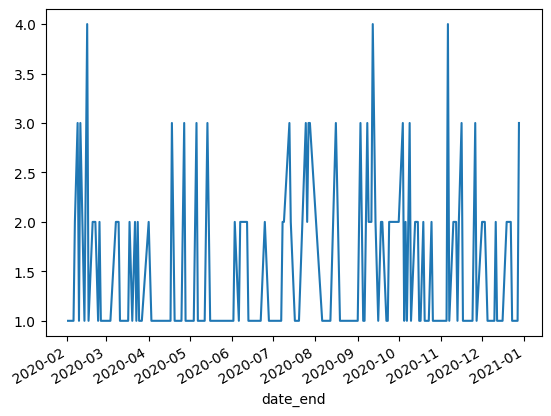

In [ ]:
subscriptions.groupby('date_end')['client_id'].count().sort_index().plot()

In [ ]:
subscriptions['amount'].describe()

,amount
count,1308.000000
mean,2263.853211
std,3112.970861
min,149.000000
25%,169.000000
50%,169.000000
75%,4331.000000
max,9984.000000


In [ ]:
subscriptions

,id,client_id,product_category,product_company,amount,date_start,date_end
0,766278,825,29,Неизвестно,3990,2012-01-25,NaT
1,658393,709,4,Яндекс.Музыка,199,2012-01-27,2020-02-27
2,354548,383,4,Boom,149,2012-01-28,NaT
3,515830,556,4,Spotify,169,2012-02-01,NaT
4,799560,862,4,YouTube Music,169,2012-02-20,2020-05-20
...,...,...,...,...,...,...,...
1303,529611,571,4,Яндекс.Музыка,199,2020-11-15,NaT
1304,427199,461,4,Spotify,169,2020-11-18,NaT
1305,464986,501,29,Неизвестно,6884,2020-11-20,NaT
1306,425121,458,29,Неизвестно,9202,2020-11-25,NaT


<Axes: >

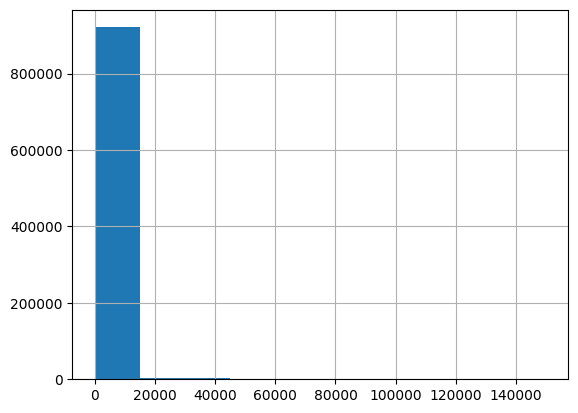

In [ ]:
transactions['amount'].hist()

<Axes: >

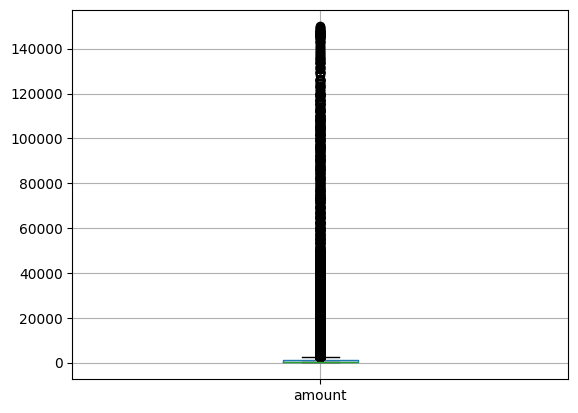

In [ ]:
pd.DataFrame(transactions['amount']).boxplot()

<Axes: >

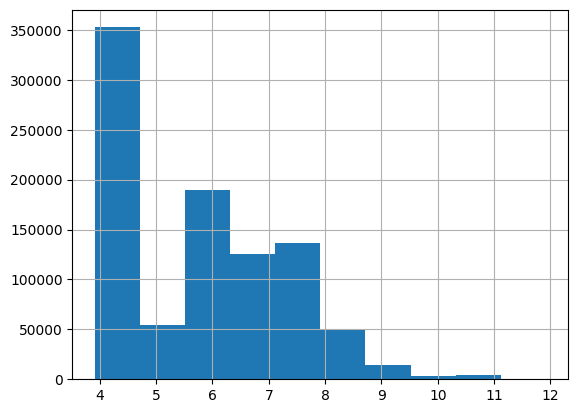

In [ ]:
np.log(transactions['amount']).hist()

In [ ]:
transactions['amount'].describe()

,amount
count,929135.000000
mean,1143.750824
std,3948.343863
min,50.000000
25%,83.000000
50%,347.000000
75%,1042.000000
max,149891.000000


In [ ]:
cat_stats  = transactions.groupby('product_category').agg(count=('amount', 'count'),total_amount=('amount', 'sum'),avg_amount=('amount', 'mean'),median_amount=('amount', 'median')).sort_values('count', ascending=False)

In [ ]:
cat_stats

,count,total_amount,avg_amount,median_amount
product_category,,,,
6,350044,26254785,75.004242,75.0
5,130137,48740746,374.534114,374.0
28,90018,136969265,1521.576407,1518.0
2,45010,121186954,2692.445101,2690.0
3,29839,17880237,599.223734,598.0
1,29563,26620827,900.477861,901.0
8,24225,9677046,399.465263,399.0
9,24208,9693442,400.423083,401.0
11,24087,36040369,1496.258106,1493.0


In [ ]:
(cat_stats['count'] / cat_stats ['count'].sum() * 100).round(1).head(5)

,count
product_category,
6,37.7
5,14.0
28,9.7
2,4.8
3,3.2


In [ ]:
transactions

,Unnamed: 0,client_id,product_category,product_company,subtype,amount,date,transaction_type,date_d
0,34478,37,29,Неизвестно,Автоплатеж,1209,2020-01-01 00:00:00,Negative,2020-01-01
1,65406,71,4,YouTube Music,Подписка,169,2020-01-01 00:00:00,Negative,2020-01-01
2,82186,88,29,Неизвестно,Автоплатеж,3711,2020-01-01 00:00:00,Negative,2020-01-01
3,83113,89,29,Неизвестно,Автоплатеж,6443,2020-01-01 00:00:00,Negative,2020-01-01
4,131373,141,29,Неизвестно,Автоплатеж,7319,2020-01-01 00:00:00,Negative,2020-01-01
...,...,...,...,...,...,...,...,...,...
929130,11637,13,6,Стрелка,Покупка,50,2020-12-31 23:58:04,Negative,2020-12-31
929131,179338,194,6,Неизвестно,Покупка,54,2020-12-31 23:58:11,Negative,2020-12-31
929132,511244,551,3,Ситимобил,Покупка,313,2020-12-31 23:58:13,Negative,2020-12-31
929133,214793,232,6,Неизвестно,Покупка,87,2020-12-31 23:59:03,Negative,2020-12-31


In [ ]:
type_stats = transactions.groupby('subtype').agg(count=('amount', 'count'),total_amount=('amount', 'sum'),avg_amount=('amount', 'mean'),median_amount=('amount', 'median')).sort_values('count', ascending=False)

In [ ]:
type_stats

,count,total_amount,avg_amount,median_amount
subtype,,,,
Покупка,825927,895792570,1084.590490,290.0
Перевод,45034,68489232,1520.833859,1522.0
Пополнение,44984,68480033,1522.319780,1514.0
Подписка,8004,1350156,168.685157,169.0
Автоплатеж,5186,28586931,5512.327613,5674.0


In [ ]:
monthly = transactions.groupby(transactions['date'].dt.to_period('M')).agg(
    count=('amount', 'count'),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    median_amount=('amount', 'median'),
    uniq_user=('client_id','nunique')
).sort_values('count', ascending=False)

In [ ]:
monthly

,count,total_amount,avg_amount,median_amount,uniq_user
date,,,,,
2020-10,78861,87894434,1114.548814,342.0,1000
2020-12,78851,90496209,1147.686256,348.0,1000
2020-08,78797,90615110,1149.981725,352.0,1000
2020-07,78732,91093067,1157.001816,344.0,1000
2020-03,78616,92501151,1176.619912,347.0,1000
2020-01,78503,88091906,1122.147001,347.0,1000
2020-05,78474,89081397,1135.170846,343.0,1000
2020-11,76211,87252573,1144.881618,347.0,1000
2020-04,76152,86437845,1135.069926,352.0,1000


<Axes: xlabel='date'>

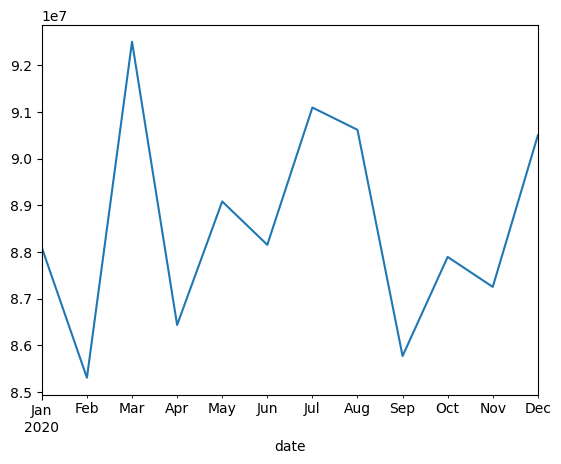

In [ ]:
monthly.sort_values('date')['total_amount'].plot()

<Axes: xlabel='date'>

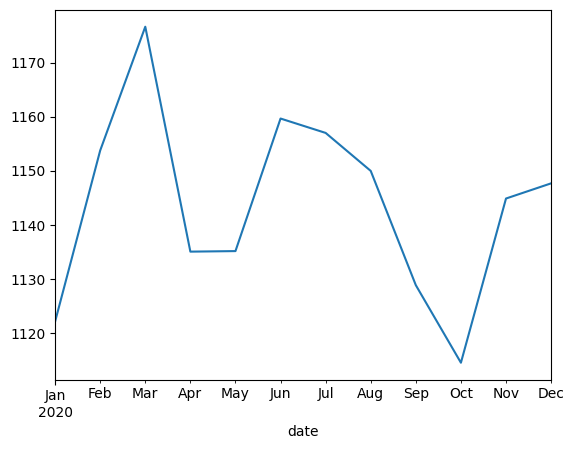

In [ ]:
monthly.sort_values('date')['avg_amount'].plot()

<Axes: xlabel='date'>

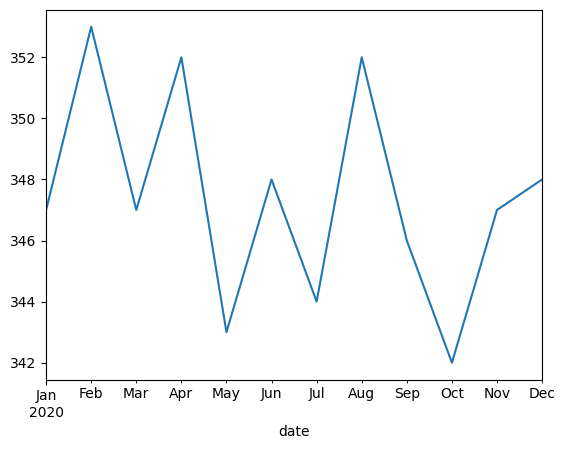

In [ ]:
monthly.sort_values('date')['median_amount'].plot()

<Axes: xlabel='date'>

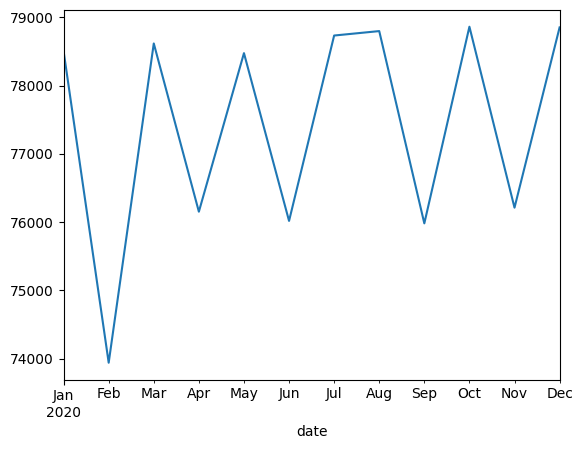

In [ ]:
monthly.sort_values('date')['count'].plot()

<Axes: xlabel='date'>

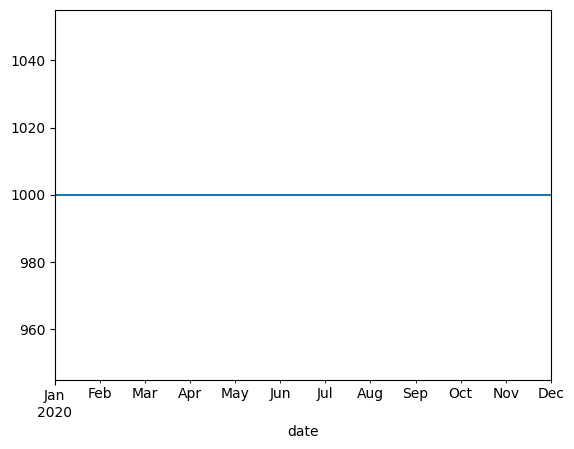

In [ ]:
monthly.sort_values('date')['uniq_user'].plot()

In [ ]:
days=transactions.groupby(transactions['date'].dt.dayofweek).agg(
    count=('amount', 'count'),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    median_amount=('amount', 'median'),
    uniq_user=('client_id','nunique')
).sort_values('date')

In [ ]:
days

,count,total_amount,avg_amount,median_amount,uniq_user
date,,,,,
0,132442,151501996,1143.912022,349.0,1000
1,132261,149878025,1133.198940,347.0,1000
2,134365,151557681,1127.955055,347.0,1000
3,133752,154026893,1151.585718,349.0,1000
4,132359,149690800,1130.945383,347.0,1000
5,131926,153001888,1159.755378,347.0,1000
6,132030,153041639,1159.142914,345.0,1000


<Axes: xlabel='date'>

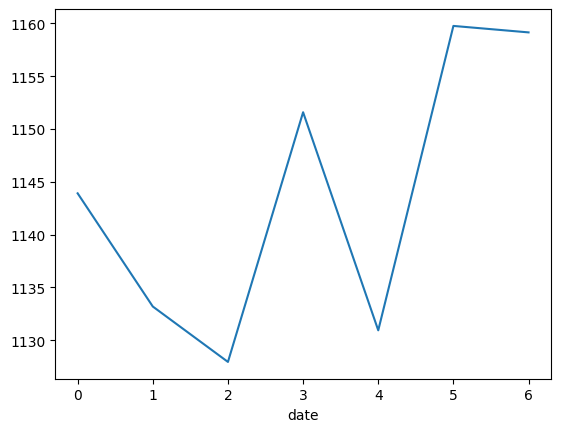

In [ ]:
days.sort_values('date')['avg_amount'].plot()

In [ ]:
hours = transactions.groupby(transactions['date'].dt.hour).agg(
    count=('amount', 'count'),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    median_amount=('amount', 'median'),
    uniq_user=('client_id','nunique')
).sort_values('date')

In [ ]:
hours

,count,total_amount,avg_amount,median_amount,uniq_user
date,,,,,
0,51230,72712439,1419.333184,293.0,1000
1,38223,42925659,1123.032180,352.0,1000
2,37995,43413602,1142.613554,354.0,1000
3,38562,42628586,1105.455785,347.0,1000
4,38352,42632559,1111.612406,351.0,1000
5,38281,43038311,1124.273425,355.0,1000
6,38284,42418116,1107.985477,349.0,1000
7,37817,41425391,1095.417167,345.0,1000
8,37596,42414528,1128.165975,343.0,1000


<Axes: xlabel='date'>

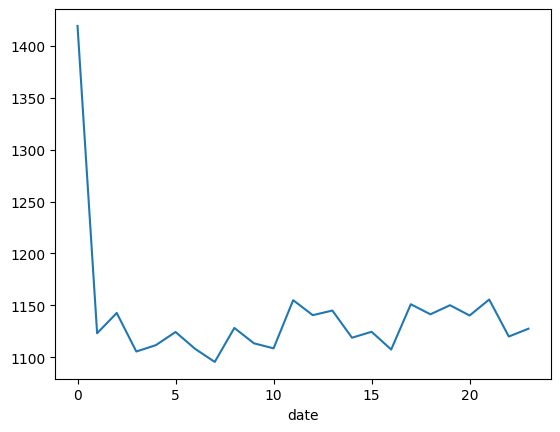

In [ ]:
hours['avg_amount'].plot()

<Axes: xlabel='date', ylabel='date'>

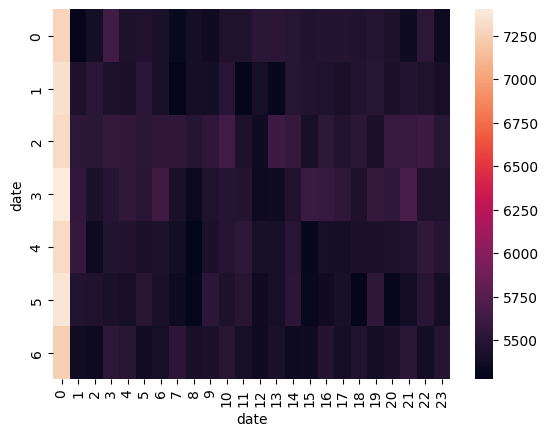

In [ ]:
sns.heatmap(transactions.pivot_table(
    values='amount', index=transactions['date'].dt.dayofweek, columns=transactions['date'].dt.hour,
    aggfunc='count'
))

<Axes: xlabel='date', ylabel='date'>

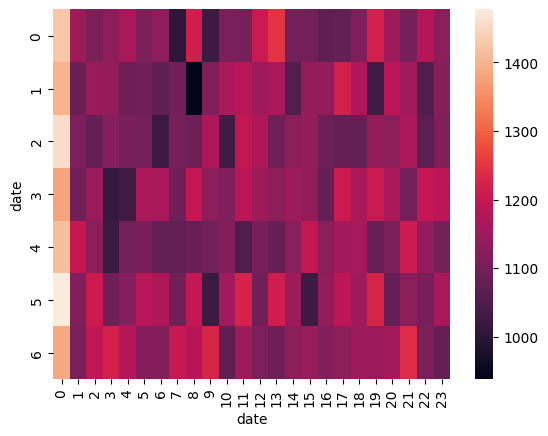

In [ ]:
sns.heatmap(transactions.pivot_table(
    values='amount', index=transactions['date'].dt.dayofweek, columns=transactions['date'].dt.hour,
    aggfunc='mean'
))

In [ ]:
pd.cut(
    transactions['date'].dt.day,
    bins=[0, 10, 20, 31],
    labels=['начало', 'середина', 'конец']
)

,date
0,начало
1,начало
2,начало
3,начало
4,начало
...,...
929130,конец
929131,конец
929132,конец
929133,конец


In [ ]:
transactions.groupby(pd.cut(
    transactions['date'].dt.day,
    bins=[0, 10, 20, 31],
    labels=['начало', 'середина', 'конец']
), observed=True).agg(
    count=('amount', 'count'),
    avg_amount=('amount', 'mean'),
    total=('amount', 'sum')
)

,count,avg_amount,total
date,,,
начало,304496,1132.596645,344871148
середина,305224,1153.410964,352048708
конец,319415,1145.153064,365779066


In [ ]:
transactions['date'].dt.day_of_week.isin([5, 6]).astype(int)

,date
0,0
1,0
2,0
3,0
4,0
...,...
929130,0
929131,0
929132,0
929133,0


In [ ]:
transactions.groupby(transactions['date'].dt.day_of_week.isin([5, 6])).agg(
    count=('amount', 'count'),
    avg_amount=('amount', 'mean'),
    median_amount=('amount', 'median'),
    total=('amount', 'sum')
)

,count,avg_amount,median_amount,total
date,,,,
False,665179,1137.521472,348.0,756655395
True,263956,1159.449026,346.0,306043527


In [ ]:
transactions

,Unnamed: 0,client_id,product_category,product_company,subtype,amount,date,transaction_type,date_d
0,34478,37,29,Неизвестно,Автоплатеж,1209,2020-01-01 00:00:00,Negative,2020-01-01
1,65406,71,4,YouTube Music,Подписка,169,2020-01-01 00:00:00,Negative,2020-01-01
2,82186,88,29,Неизвестно,Автоплатеж,3711,2020-01-01 00:00:00,Negative,2020-01-01
3,83113,89,29,Неизвестно,Автоплатеж,6443,2020-01-01 00:00:00,Negative,2020-01-01
4,131373,141,29,Неизвестно,Автоплатеж,7319,2020-01-01 00:00:00,Negative,2020-01-01
...,...,...,...,...,...,...,...,...,...
929130,11637,13,6,Стрелка,Покупка,50,2020-12-31 23:58:04,Negative,2020-12-31
929131,179338,194,6,Неизвестно,Покупка,54,2020-12-31 23:58:11,Negative,2020-12-31
929132,511244,551,3,Ситимобил,Покупка,313,2020-12-31 23:58:13,Negative,2020-12-31
929133,214793,232,6,Неизвестно,Покупка,87,2020-12-31 23:59:03,Negative,2020-12-31


In [ ]:
transactions

,Unnamed: 0,client_id,product_category,product_company,subtype,amount,date,transaction_type,date_d
0,34478,37,29,Неизвестно,Автоплатеж,1209,2020-01-01 00:00:00,Negative,2020-01-01
1,65406,71,4,YouTube Music,Подписка,169,2020-01-01 00:00:00,Negative,2020-01-01
2,82186,88,29,Неизвестно,Автоплатеж,3711,2020-01-01 00:00:00,Negative,2020-01-01
3,83113,89,29,Неизвестно,Автоплатеж,6443,2020-01-01 00:00:00,Negative,2020-01-01
4,131373,141,29,Неизвестно,Автоплатеж,7319,2020-01-01 00:00:00,Negative,2020-01-01
...,...,...,...,...,...,...,...,...,...
929130,11637,13,6,Стрелка,Покупка,50,2020-12-31 23:58:04,Negative,2020-12-31
929131,179338,194,6,Неизвестно,Покупка,54,2020-12-31 23:58:11,Negative,2020-12-31
929132,511244,551,3,Ситимобил,Покупка,313,2020-12-31 23:58:13,Negative,2020-12-31
929133,214793,232,6,Неизвестно,Покупка,87,2020-12-31 23:59:03,Negative,2020-12-31
